In [1]:
import torch 
import numpy as np
import struct
from torch.utils.data import TensorDataset, DataLoader
import torch.utils.data
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn

In [2]:
import wandb
from kaggle_secrets import UserSecretsClient
secret_label = "WANDB_API_KEY"
secret_value = UserSecretsClient().get_secret(secret_label)
import os
os.environ["WANDB_API_KEY"] = secret_value
wandb.login()

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

True

In [3]:
def load_fashiondata():
    def load_images(path):
        with open(path, 'rb') as f:
            magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28, 28)
            return images

    def load_labels(path):
        with open(path, 'rb') as f:
            magic, num = struct.unpack('>II', f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)
            return labels

    # Load raw Fashion-MNIST data files
    train_images = load_images("/kaggle/input/fashionmnist/train-images-idx3-ubyte")
    train_labels = load_labels("/kaggle/input/fashionmnist/train-labels-idx1-ubyte")
    test_images  = load_images("/kaggle/input/fashionmnist/t10k-images-idx3-ubyte")
    test_labels  = load_labels("/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte")

    # Convert to tensors and normalize
    train_images_tensor = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1) / 255.0
    train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
    test_images_tensor = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1) / 255.0
    test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

    # Combine into datasets
    full_train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)
    test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)

    # Split into train (90%) and validation (10%)
    total_train = len(full_train_dataset)
    val_size = int(0.1 * total_train)
    train_size = total_train - val_size
    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)  # ensures reproducibility
    )

    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset

In [4]:
# random transform
train_transforms = transforms.Compose([
    transforms.Pad(2, fill=0),         # Pad to 32x32
    transforms.RandomCrop(28),       # Randomly crop back to 28x28
    transforms.RandomRotation(10)      # Rotate +/- 10 degrees
])

# empty transform for val_test
val_test_transforms = transforms.Compose([])

class FashionMNISTDataset(Dataset):
    """
    Wraps a base Fashion-MNIST dataset to return three items:
    (normalized_image, class_label, ink_target)
    """
    def __init__(self, base_dataset,transform=None):
        super().__init__()
        self.base_dataset = base_dataset
        self.transform = transform
        
        # Define the normalization values for Fashion-MNIST
        self.mean = 0.2860
        self.std = 0.3530
        
        # Define the normalization transform
        self.normalize_transform = transforms.Normalize((self.mean,), (self.std,))

    def __len__(self):
        # Return the length of the base dataset
        return len(self.base_dataset)

    
    def __getitem__(self, idx):
        # 1. Get the original item (image_0_1, label)
        image_tensor_0_1, label = self.base_dataset[idx]
        
        # 2. APPLY AUGMENTATIONS (if a transform was provided)
        if self.transform:
            image_tensor_0_1 = self.transform(image_tensor_0_1)
        
        # 3. Calculate 'ink target'
        ink_target = torch.mean(image_tensor_0_1)
        
        # 4. Create the final 'normalized_image'
        normalized_image = self.normalize_transform(image_tensor_0_1)
        
        # 5. Return the 3-part tuple
        return normalized_image, label, ink_target

In [5]:
base_train_set, base_val_set, base_test_set = load_fashiondata()

#    This now creates datasets that return (normalized_image, label, ink_target)
train_dataset = FashionMNISTDataset(base_train_set , transform = train_transforms)
val_dataset = FashionMNISTDataset(base_val_set , transform = val_test_transforms)
test_dataset = FashionMNISTDataset(base_test_set, transform = val_test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    num_workers=2,      # try 2 if system is slow
    pin_memory=True,    # speeds up transfer to GPU
    prefetch_factor=2   # optional, preloads batches in advance
)


#Get one batch to inspect the three outputs
images, labels, inks = next(iter(train_loader))

print("\n--- Test results from one batch ---")
print(f"Images batch shape:  {images.shape}")
print(f"Labels batch shape:  {labels.shape}")
print(f"Inks batch shape:    {inks.shape}")

Train: 54000, Val: 6000, Test: 10000

--- Test results from one batch ---
Images batch shape:  torch.Size([1024, 1, 28, 28])
Labels batch shape:  torch.Size([1024])
Inks batch shape:    torch.Size([1024])


In [6]:
class MultiTaskNN(nn.Module):
    # We add params for filter sizes and dropout
    def __init__(self, input_features=1, filters1=32, filters2=64, dropout_rate=0.25):
        super().__init__()

        # 1. SHARED BODY: Built using the hyperparams
        self.features = nn.Sequential(
            nn.Conv2d(input_features, filters1, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(filters1),
            nn.MaxPool2d(kernel_size=2, stride=2), # -> 14x14

            nn.Conv2d(filters1, filters2, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(filters2),
            nn.MaxPool2d(kernel_size=2, stride=2) # -> 7x7
        )
        
        # Flattened size depends on the number of filters
        flattened_size = filters2 * 7 * 7 

        # 2. SHARED HEAD
        self.shared_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate) # Use the dropout hyperparam
        )

        # 3. TASK-SPECIFIC HEADS
        self.class_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
        self.ink_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.shared_head(x)
        class_output = self.class_head(x)
        ink_output = self.ink_head(x)
        return class_output, ink_output

In [7]:
# Define the hyperparameter search space
sweep_config = {
    'method': 'bayes',  #  'bayes' 
    'metric': {
      'name': 'val/total_loss', # <-- CHANGED to match your wandb.log
      'goal': 'minimize'      # 
    },
    'parameters': {
        'optimizer': {
            'values': ['adam', 'sgd', 'adamw']
        },
        'batch_size': {
            'values': [32, 64, 128,256]
        },
        'learning_rate': {
            'distribution': 'log_uniform_values',
            'min': 1e-4,
            'max': 1e-1
        },
        'dropout_rate': {
            'distribution': 'uniform',
            'min': 0.1,
            'max': 0.5
        },
        'filters1': {
            'values': [16, 32]
        },
        'filters2': {
            'values': [32, 64, 128]
        },
        'lambda_1': { # Weight for Classification (CE) Loss
            'value': 1.0  # We'll fix this and vary the other
        },
        'lambda_2': { # Weight for Ink (MSE) Loss
            'distribution': 'uniform',
            'min': 0.5,
            'max': 20.0
        },
        'epochs': {
            'value': 25 # Fix epochs for a fair comparison
        }
    }
}

In [8]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Using device: cuda


In [9]:
# Make sure 'import os' is in your first cell!

def train_and_test():
    # Initialize a new wandb run
    with wandb.init() as run:
        config = wandb.config # Get the hyperparameters for this run

        # --- Create a unique model save path for this run ---\
        model_save_path = f"best_model_{run.id}.pth"

        # --- 1. Setup DataLoaders ---\
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True, num_workers=4, pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=config.batch_size,
            shuffle=False, num_workers=4, pin_memory=True
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.batch_size,
            shuffle=False, num_workers=4, pin_memory=True
        )

        # --- 2. Setup Model ---\
        model = MultiTaskNN(
            filters1=config.filters1,
            filters2=config.filters2,
            dropout_rate=config.dropout_rate
        ).to(device)

        # --- 3. Setup Optimizer ---\
        if config.optimizer == 'adam':
            optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
        elif config.optimizer == 'sgd':
            optimizer = optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9)
        elif config.optimizer == 'adamw':
            optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate)

        # --- 4. Setup Loss Functions ---\
        criterion_class = nn.CrossEntropyLoss()
        criterion_ink_mse = nn.MSELoss() # For MSE and RMSE
        criterion_ink_mae = nn.L1Loss()  # For MAE

        best_val_loss = float('inf')

        # --- 5. Training & Validation Loop ---\
        print(f"--- Starting Run: {run.name} ({run.id}) ---")
        for epoch in range(config.epochs):
            # --- Training ---\
            model.train()
            train_loss, train_ce, train_mse = 0.0, 0.0, 0.0
            for images, labels, inks in train_loader:
                images, labels, inks = images.to(device), labels.to(device), inks.to(device)
                
                class_preds, ink_preds = model(images)
                
                loss_c = criterion_class(class_preds, labels)
                loss_i = criterion_ink_mse(ink_preds.squeeze(), inks.float())
                
                total_loss = (config.lambda_1 * loss_c) + (config.lambda_2 * loss_i)
                
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()
                
                train_loss += total_loss.item() * images.size(0)
                train_ce += loss_c.item() * images.size(0)
                train_mse += loss_i.item() * images.size(0)
            
            # --- Validation ---\
            model.eval()
            val_loss, val_ce, val_mse, val_mae = 0.0, 0.0, 0.0, 0.0
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels, inks in val_loader:
                    images, labels, inks = images.to(device), labels.to(device), inks.to(device)
                    
                    class_preds, ink_preds = model(images)
                    
                    loss_c = criterion_class(class_preds, labels)
                    loss_i_mse = criterion_ink_mse(ink_preds.squeeze(), inks.float())
                    loss_i_mae = criterion_ink_mae(ink_preds.squeeze(), inks.float())
                    
                    total_loss = (config.lambda_1 * loss_c) + (config.lambda_2 * loss_i_mse)
                    
                    val_loss += total_loss.item() * images.size(0)
                    val_ce += loss_c.item() * images.size(0)
                    val_mse += loss_i_mse.item() * images.size(0)
                    val_mae += loss_i_mae.item() * images.size(0)
                    
                    _, predicted = torch.max(class_preds.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # --- Calculate all average metrics for logging ---\
            avg_train_loss = train_loss / len(train_dataset)
            avg_train_ce = train_ce / len(train_dataset)
            avg_train_mse = train_mse / len(train_dataset)
            
            avg_val_loss = val_loss / len(val_dataset) 
            avg_val_ce = val_ce / len(val_dataset)
            avg_val_mse = val_mse / len(val_dataset)
            avg_val_mae = val_mae / len(val_dataset)
            
            val_accuracy = 100 * correct / total
            val_rmse = np.sqrt(avg_val_mse)

            # --- 6. wandb Logging (per epoch) ---\
            wandb.log({
                "epoch": epoch + 1,
                "train/total_loss": avg_train_loss,
                "val/total_loss": avg_val_loss, 
                "train/ce_loss": avg_train_ce,
                "val/ce_loss": avg_val_ce,
                "train/mse_loss": avg_train_mse,
                "val/mse_loss": avg_val_mse,
                "val/accuracy": val_accuracy,
                "val/mae": avg_val_mae,
                "val/rmse": val_rmse
            })
            
            # --- Save best model ---
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                
                # --- Save to the unique local path ---\
                torch.save(model.state_dict(), model_save_path)
                
                # --- Tell wandb this is the best score so far ---
                wandb.run.summary["best_val_loss"] = best_val_loss
                wandb.run.summary["best_val_accuracy"] = val_accuracy
                
                # --- *** THE FIX IS HERE *** ---
                best_model_artifact = wandb.Artifact(
                    name=f"best_model_{run.id}", 
                    type="model",
                    metadata=dict(config) # <-- Changed from config.to_dict()
                )
                best_model_artifact.add_file(model_save_path) 
                run.log_artifact(best_model_artifact, aliases=['best']) 
                # --- *** END OF FIX *** ---


        print(f"Run {run.name} finished. Best Val Loss: {best_val_loss:.4f}")

        # --- 7. Final Test Evaluation ---\
        
        # --- Load from the unique local path ---
        if os.path.exists(model_save_path): 
            model.load_state_dict(torch.load(model_save_path))
            model.eval()
            
            test_loss, test_ce, test_mse, test_mae = 0.0, 0.0, 0.0, 0.0
            all_labels = []
            all_preds = []
            all_ink_targets = []
            all_ink_preds = []
            
            with torch.no_grad():
                for images, labels, inks in test_loader:
                    images, labels, inks = images.to(device), labels.to(device), inks.to(device)
                    
                    class_preds, ink_preds = model(images)
                    
                    loss_c = criterion_class(class_preds, labels)
                    loss_i_mse = criterion_ink_mse(ink_preds.squeeze(), inks.float())
                    loss_i_mae = criterion_ink_mae(ink_preds.squeeze(), inks.float())
                    total_loss = (config.lambda_1 * loss_c) + (config.lambda_2 * loss_i_mse)
                    
                    test_loss += total_loss.item() * images.size(0)
                    test_ce += loss_c.item() * images.size(0)
                    test_mse += loss_i_mse.item() * images.size(0)
                    test_mae += loss_i_mae.item() * images.size(0)
                    
                    _, predicted = torch.max(class_preds.data, 1)
                    
                    # Store for visualizations
                    all_labels.extend(labels.cpu().numpy())
                    all_preds.extend(predicted.cpu().numpy())
                    all_ink_targets.extend(inks.cpu().numpy())
                    all_ink_preds.extend(ink_preds.squeeze().cpu().numpy())

            # --- Calculate final test metrics ---
            avg_test_loss = test_loss / len(test_dataset)
            avg_test_ce = test_ce / len(test_dataset)
            avg_test_mse = test_mse / len(test_dataset)
            avg_test_mae = test_mae / len(test_dataset)
            test_accuracy = 100 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
            test_rmse = np.sqrt(avg_test_mse)

            # --- 8. Final wandb Logging (Test Performance & Visuals) ---\
            wandb.log({
                "test/accuracy": test_accuracy,
                "test/total_loss": avg_test_loss,
                "test/ce_loss": avg_test_ce,
                "test/mse_loss": avg_test_mse,
                "test/mae": avg_test_mae,
                "test/rmse": test_rmse
            })

            # --- Log Visualizations ---\
            wandb.log({
                "test/confusion_matrix": wandb.plot.confusion_matrix(
                    probs=None,
                    y_true=all_labels,
                    preds=all_preds,
                    class_names=class_names
                )
            })
            
            ink_data = [[target, pred] for (target, pred) in zip(all_ink_targets, all_ink_preds)]
            table = wandb.Table(data=ink_data, columns = ["Actual Ink", "Predicted Ink"])
            wandb.log({
                "test/ink_scatter_plot": wandb.plot.scatter(
                    table, "Actual Ink", "Predicted Ink",
                    title="Actual vs. Predicted Ink"
                )
            })
            
            # --- Clean up the local saved model file ---\
            os.remove(model_save_path)
            
        else:
            print(f"Run {run.name} did not save a model (val_loss never improved). Skipping test.")

In [10]:
# Define your project name
project_name = "A4Ques1" 

# 1. This tells wandb about your sweep_config and gives you a sweep_id
sweep_id = wandb.sweep(sweep_config, project=project_name)

# 2. Run the agent
# This will call your 'train_and_test' function `count` times.
print(f"--- Starting Sweep Agent for Sweep ID: {sweep_id} ---\n")
wandb.agent(sweep_id, function=train_and_test, count=10) # Runs 10 agents

print("--- Sweep Finished ---")

Create sweep with ID: wbpppy1g
Sweep URL: https://wandb.ai/iiithyderabad12/A4Ques1/sweeps/wbpppy1g
--- Starting Sweep Agent for Sweep ID: wbpppy1g ---



wandb: Agent Starting Run: xenodrpo with config:
wandb: 	batch_size: 32
wandb: 	dropout_rate: 0.14244136820543785
wandb: 	epochs: 25
wandb: 	filters1: 32
wandb: 	filters2: 128
wandb: 	lambda_1: 1
wandb: 	lambda_2: 14.680943002214374
wandb: 	learning_rate: 0.00013924162602581272
wandb: 	optimizer: adam


--- Starting Run: sandy-sweep-1 (xenodrpo) ---
Run sandy-sweep-1 finished. Best Val Loss: 0.2004


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
test/accuracy,▁
test/ce_loss,▁
test/mae,▁
test/mse_loss,▁
test/rmse,▁
test/total_loss,▁
train/ce_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/mse_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▄▅▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇█


wandb: Agent Starting Run: 2bxbfqvj with config:
wandb: 	batch_size: 32
wandb: 	dropout_rate: 0.11260493358324344
wandb: 	epochs: 25
wandb: 	filters1: 32
wandb: 	filters2: 128
wandb: 	lambda_1: 1
wandb: 	lambda_2: 9.565318571520178
wandb: 	learning_rate: 0.018104238622197164
wandb: 	optimizer: adam


...

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
test/accuracy,▁
test/ce_loss,▁
test/mae,▁
test/mse_loss,▁
test/rmse,▁
test/total_loss,▁
train/ce_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/mse_loss,█▅▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇█████████


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: unu4dwvb with config:
wandb: 	batch_size: 32
wandb: 	dropout_rate: 0.28018911880448216
wandb: 	epochs: 25
wandb: 	filters1: 32
wandb: 	filters2: 128
wandb: 	lambda_1: 1
wandb: 	lambda_2: 19.933659786736
wandb: 	learning_rate: 0.0001115180268944462
wandb: 	optimizer: adam


--- Starting Run: divine-sweep-10 (unu4dwvb) ---
Run divine-sweep-10 finished. Best Val Loss: 0.2472


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
test/accuracy,▁
test/ce_loss,▁
test/mae,▁
test/mse_loss,▁
test/rmse,▁
test/total_loss,▁
train/ce_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/mse_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇█▇█▇▇████


--- Sweep Finished ---


wandb: Sorting runs by -summary_metrics.val/total_loss


--- Finding Best Run from Sweep ---
Best run found: 2bxbfqvj
Best validation loss: 1.7146
Best hyperparameters: {'epochs': 25, 'filters1': 32, 'filters2': 128, 'lambda_1': 1, 'lambda_2': 9.565318571520178, 'optimizer': 'adam', 'batch_size': 32, 'dropout_rate': 0.11260493358324344, 'learning_rate': 0.018104238622197164}



wandb:   1 of 1 files downloaded.  


Model downloaded to: /kaggle/working/artifacts/best_model_2bxbfqvj:v3/best_model_2bxbfqvj.pth
Loading best model...
Model loaded successfully.

Running model to capture feature maps...

--- Visualizations for Test Image 1 (Label: Ankle boot) ---


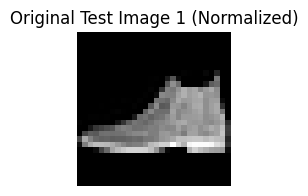

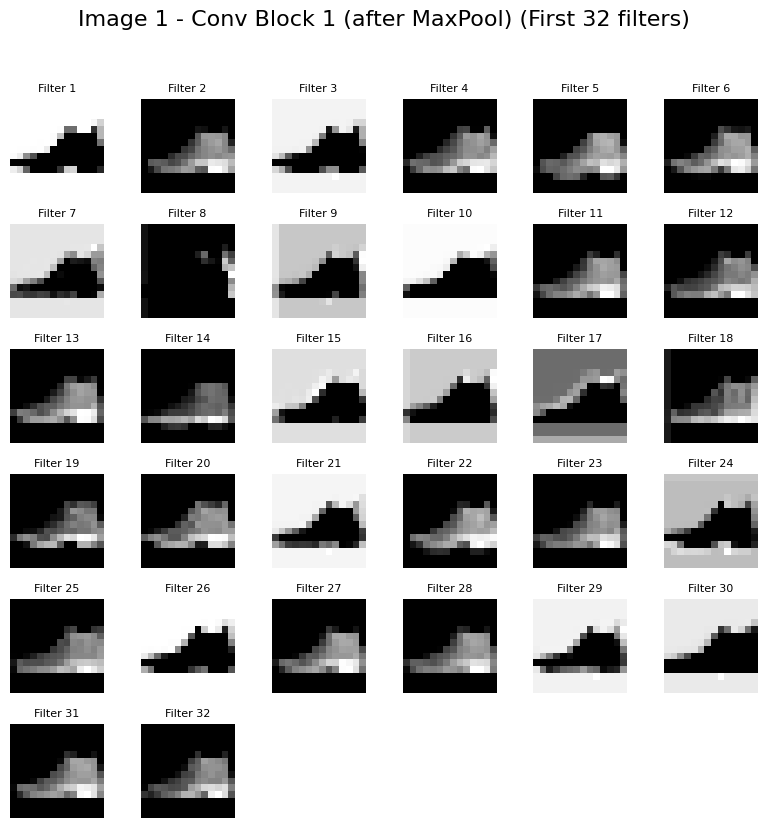

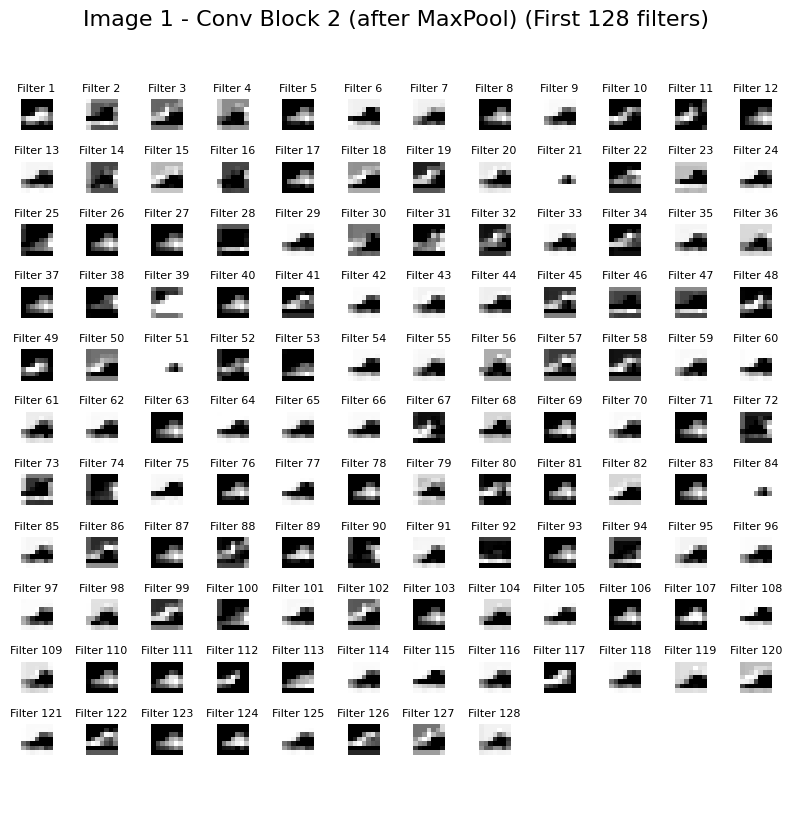

------------------------------------------------------------

--- Visualizations for Test Image 2 (Label: Pullover) ---


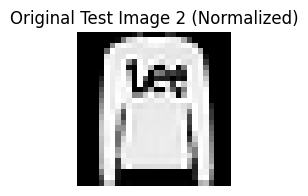

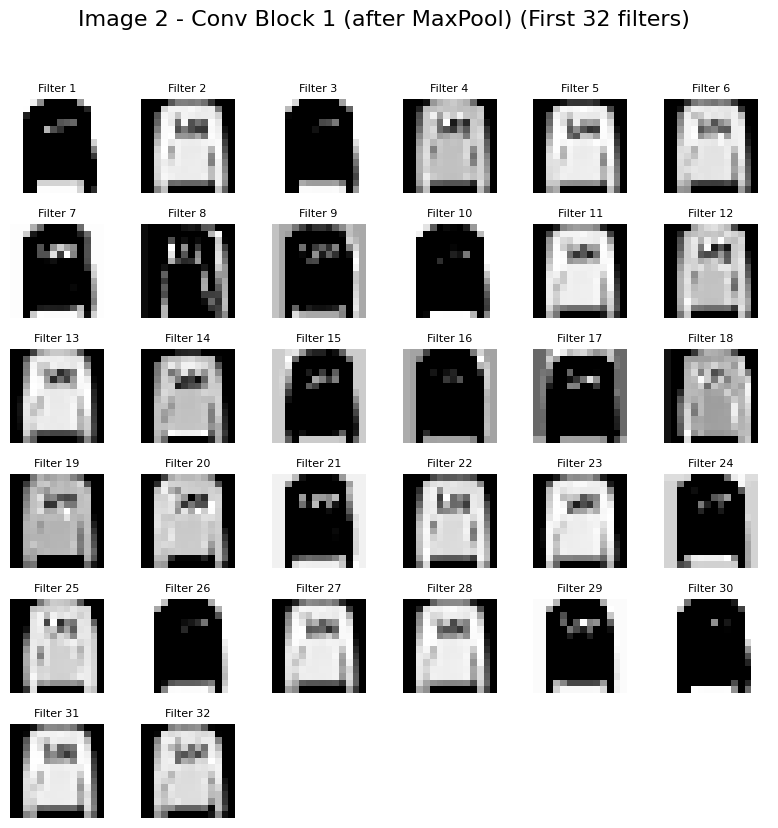

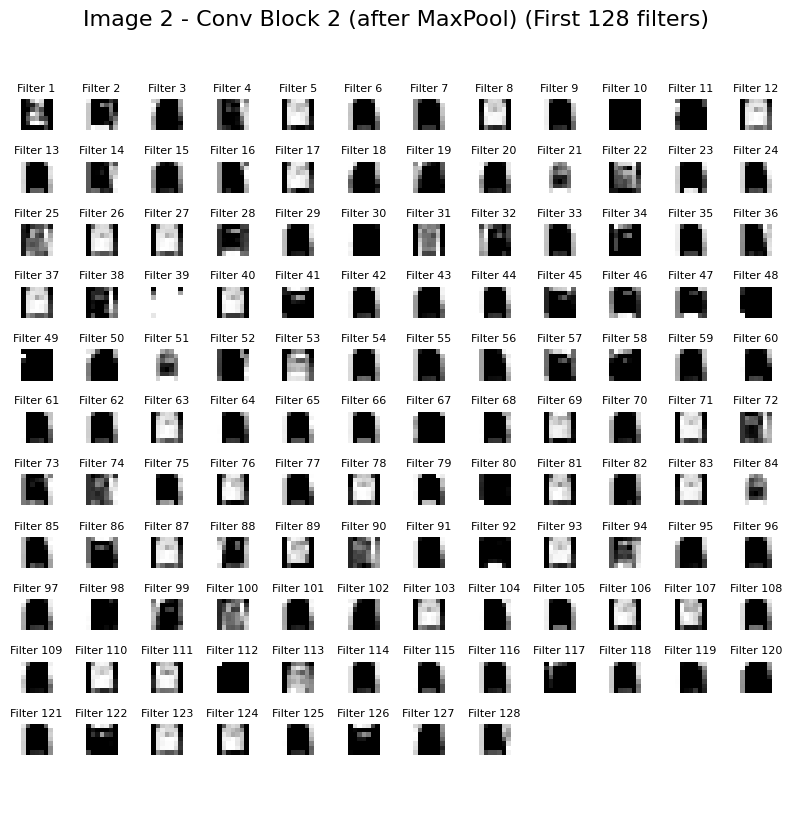

------------------------------------------------------------

--- Visualizations for Test Image 3 (Label: Trouser) ---


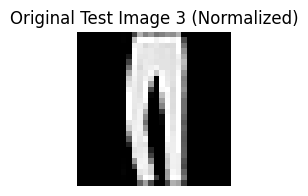

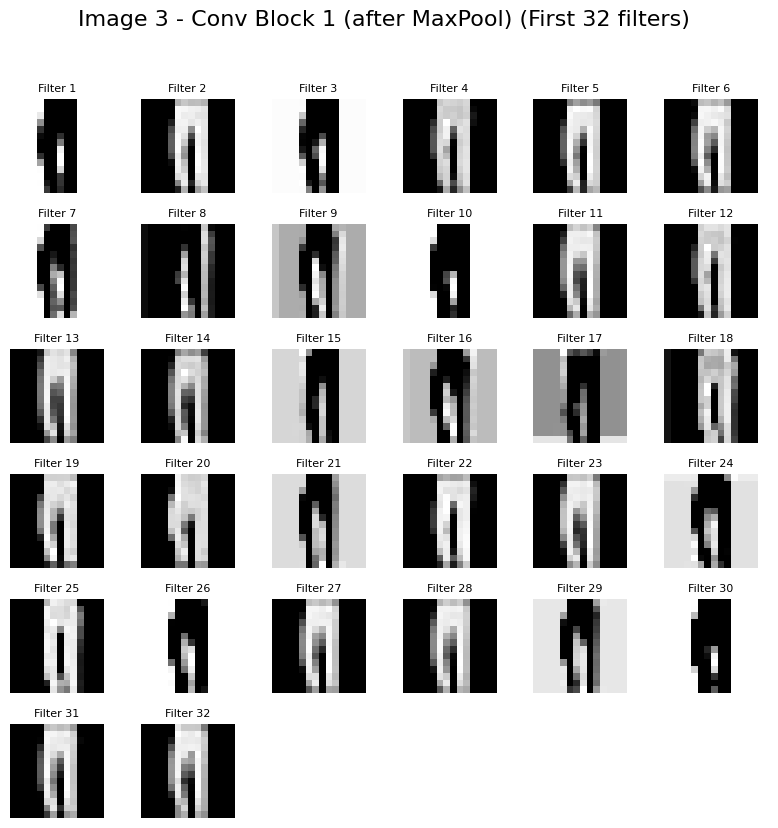

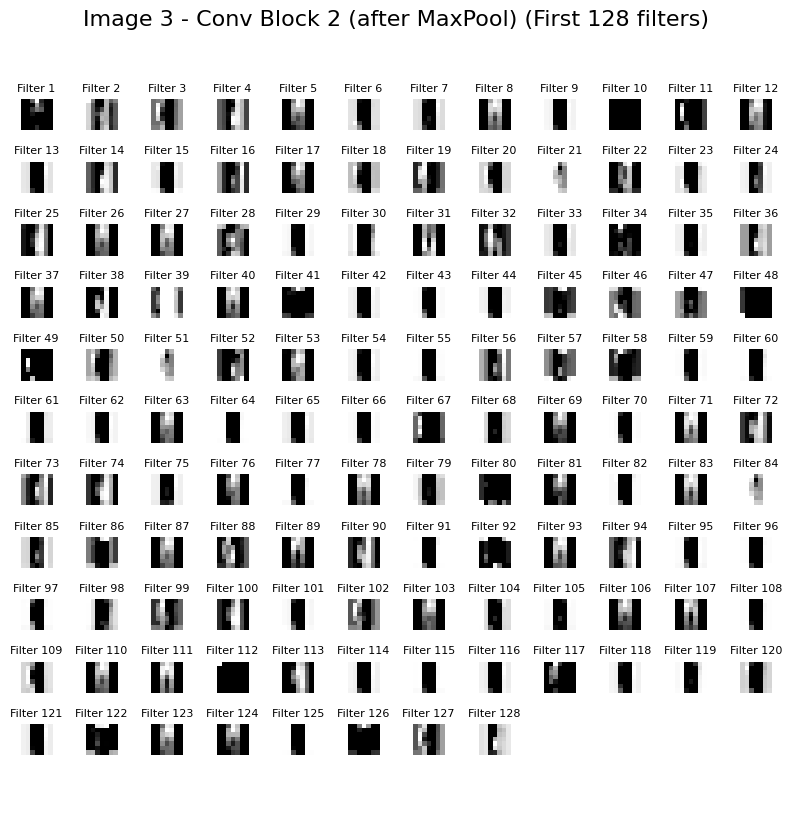

------------------------------------------------------------

Visualization complete.


In [ ]:
# --- 0. Helper function to plot feature maps (from your original cell) ---
def plot_feature_maps(f_maps, img_index, block_name, max_filters=16):
    """Plots the first 'max_filters' from a feature map batch."""
    # Get the maps for the specified image
    f_map = f_maps[img_index].cpu().numpy()
    
    # Limit to 'max_filters' or total filters
    num_filters = min(f_map.shape[0], max_filters)
    
    # Create a grid (e.g., 4x4 for 16 filters)
    grid_size = int(np.ceil(np.sqrt(num_filters)))
    fig, axes = plt.subplots(grid_size, grid_size, 
                           figsize=(8, 8))
    
    fig.suptitle(f"Image {img_index+1} - {block_name} (First {num_filters} filters)",
                 fontsize=16, y=1.03)
    
    # Handle case of a single filter
    if grid_size == 1:
        axes = np.array([[axes]])
    # Handle case of a single row/column
    if len(axes.shape) == 1:
        axes = axes.reshape(1, -1) if grid_size > 1 else axes.reshape(1, 1)

    # Flatten axes array for easy iteration
    axes_flat = axes.flatten()

    for i in range(num_filters):
        ax = axes_flat[i]
        ax.imshow(f_map[i, :, :], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Filter {i+1}", fontsize=8)
        
    # Turn off unused subplots
    for i in range(num_filters, grid_size*grid_size):
        axes_flat[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# --- 1. Get the Best Run from the Sweep ---
print("--- Finding Best Run from Sweep ---")
api = wandb.Api()
# You must fill in your W&B entity (username or team name) here
WANDB_ENTITY = "iiithyderabad12" # <-- !! REPLACE WITH YOUR ENTITY !!

sweep_path = f"{WANDB_ENTITY}/{project_name}/{sweep_id}"
sweep = api.sweep(sweep_path)

# Find the best run based on the metric defined in your sweep config
# We use 'val/total_loss' and 'minimize'
best_run = sweep.best_run(order="val/total_loss")

print(f"Best run found: {best_run.id}")
print(f"Best validation loss: {best_run.summary['best_val_loss']:.4f}")
print("Best hyperparameters:", best_run.config)

# --- 2. Download the Best Model Artifact ---
print(f"\nDownloading artifact for run {best_run.id}...")
artifact_path = f"{WANDB_ENTITY}/{project_name}/best_model_{best_run.id}:latest"
artifact = api.artifact(artifact_path)

# Download the artifact to a local directory named ./artifacts/
artifact_dir = artifact.download()
best_model_path = os.path.join(artifact_dir, f"best_model_{best_run.id}.pth")
print(f"Model downloaded to: {best_model_path}")

# --- 3. Load the best model ---
best_params = best_run.config
print("Loading best model...")
model = MultiTaskNN(
    filters1=best_params['filters1'],
    filters2=best_params['filters2'],
    dropout_rate=best_params['dropout_rate']
)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully.")

# --- 4. Set up the hooks ---
features = {}
def get_features(name):
    """Helper function to create a hook that saves layer outputs."""
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

model.features[3].register_forward_hook(get_features('conv_block_1'))
model.features[7].register_forward_hook(get_features('conv_block_2'))

# --- 5. Get 3 Test Images ---
# Uses the global 'test_dataset'
test_loader_viz = DataLoader(
    test_dataset,
    batch_size=3, # We only need 3 images
    shuffle=False 
)
images, labels, _ = next(iter(test_loader_viz))
test_images = images.to(device)
test_labels = labels

# --- 6. Run the model to trigger the hooks ---
print("\nRunning model to capture feature maps...")
features = {} # Clear features dict
with torch.no_grad():
    _ = model(test_images)

# --- 7. Loop through each of the 3 images and plot ---
for i in range(3):
    print(f"\n" + "=" * 60)
    print(f"--- Visualizations for Test Image {i+1} (Label: {class_names[test_labels[i]]}) ---")
    print("=" * 60)
    
    # Plot the original image (normalized)
    plt.figure(figsize=(2, 2))
    plt.imshow(test_images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Original Test Image {i+1} (Normalized)")
    plt.axis('off')
    plt . text (
    0.95 , 0.95 , " harshit.goyal ",
    ha=’right ’, va=’top ’,
    transform =plt.gca (). transAxes ,
    fontsize =10 , color =’gray ’, alpha =0.7
    )
    plt.show()

    # Plot maps from the first convolutional block
    plot_feature_maps(features['conv_block_1'], 
                      img_index=i, 
                      block_name="Conv Block 1 (after MaxPool)",
                      max_filters=best_params['filters1']) # Use correct filter count
    
    # Plot maps from the second convolutional block
    plot_feature_maps(features['conv_block_2'], 
                      img_index=i, 
                      block_name="Conv Block 2 (after MaxPool)",
                      max_filters=best_params['filters2']) # Use correct filter count
    
    print("-" * 60)


print("\nVisualization complete.")

WANDB DASHBOARD LINK:
https://wandb.ai/iiithyderabad12/A4Ques1


## FOR BEST VALIDATION ACCURACY:
- batch_size:32
- dropout_rate:0.14244136820543785
- epochs:25
- filters1:32
- filters2:128
- lambda_1:1
- lambda_2:14.680943002214374
- learning_rate:0.00013924162602581272
- optimizer:"adam"

- best_val_accuracy:93.4
- best_val_loss:0.2003663685272137
- epoch:25
- test/accuracy:92.89
- test/ce_loss:0.20749420766234397
- test/mae:0.02088600357472897
- test/mse_loss:0.0006591140888631343
- test/rmse:0.02567321734538027
- test/total_loss:0.21717062345147137
- train/ce_loss:0.2026208106914052
- train/mse_loss:0.00029543107718281035
- train/total_loss:0.20695801735255456

## FOR LEAST REGRESSION MSE LOSS:
- batch_size:128
- dropout_rate:0.1316434064300546
- epochs:25
- filters1:32
- filters2:128
- lambda_1:1
- lambda_2:16.139271969747398
- learning_rate:0.00013094505889394483
- optimizer:"sgd"
- 
- best_val_accuracy:88.06666666666666
- best_val_loss:0.3331889817714691
- epoch:25
- test/accuracy:87.69
- test/ce_loss:0.3376816116333008
- test/confusion_matrix_table:"table-file"
- test/ink_scatter_plot_table:"table-file"
- test/mae:0.01227409183382988
- test/mse_loss:0.000243033808702603
- test/rmse:0.01558954164504534
- test/total_loss:0.34160400085449216
- train/ce_loss:0.393804130492387
- train/mse_loss:0.0005793475970556891
- train/total_loss:0.4031543791029189
- val/accuracy:88.06666666666666
- val/ce_loss:0.3290369990269343
- val/mae:0.012582408599555492
- val/mse_loss:0.00025725954802085957
- val/rmse:0.016039312579436176
- val/total_loss:0.3331889817714691